In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

df_train = pd.read_csv('../data/train_processed.csv')
df_test = pd.read_csv('../data/test_processed.csv')
print(f'Train: {df_train.shape}')
print(f'Test: {df_test.shape}')
print(f'\nColumns: {list(df_train.columns)}')
print('✅ Data loaded!')

Train: (125973, 45)
Test: (22544, 44)

Columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level', 'attack_category', 'is_attack']
✅ Data loaded!


In [2]:
# There are 3 categorical features: protocol_type, service, flag
categorical_cols = ['protocol_type', 'service', 'flag']

print('=== Unique values per categorical feature ===')
for col in categorical_cols:
    print(f'{col}: {df_train[col].nunique()} unique values')
    
# Label Encoding (convert text → numbers)
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Fit on combined train+test to handle all categories
    combined = pd.concat([df_train[col], df_test[col]])
    le.fit(combined)
    df_train[col + '_encoded'] = le.transform(df_train[col])
    df_test[col + '_encoded'] = le.transform(df_test[col])
    label_encoders[col] = le
    print(f'\n{col} mapping (first 10):')
    for i, cls in enumerate(le.classes_[:10]):
        print(f'  {cls} → {i}')

print('\n✅ Categorical features encoded!')

=== Unique values per categorical feature ===
protocol_type: 3 unique values
service: 70 unique values
flag: 11 unique values

protocol_type mapping (first 10):
  icmp → 0
  tcp → 1
  udp → 2

service mapping (first 10):
  IRC → 0
  X11 → 1
  Z39_50 → 2
  aol → 3
  auth → 4
  bgp → 5
  courier → 6
  csnet_ns → 7
  ctf → 8
  daytime → 9

flag mapping (first 10):
  OTH → 0
  REJ → 1
  RSTO → 2
  RSTOS0 → 3
  RSTR → 4
  S0 → 5
  S1 → 6
  S2 → 7
  S3 → 8
  SF → 9

✅ Categorical features encoded!


In [3]:
# Drop non-feature columns
drop_cols = ['label', 'difficulty_level', 'attack_category', 'is_attack',
             'protocol_type', 'service', 'flag']

# Encode target
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(df_train['attack_category'])
y_test = target_encoder.transform(df_test['attack_category'])

# Binary target
y_train_binary = (df_train['attack_category'] != 'Normal').astype(int).values
y_test_binary = (df_test['attack_category'] != 'Normal').astype(int).values

# Feature matrix — use errors='ignore' to skip missing columns
X_train = df_train.drop(columns=drop_cols, errors='ignore')
X_test = df_test.drop(columns=drop_cols, errors='ignore')

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'\nTarget classes: {list(target_encoder.classes_)}')
print(f'Binary split - Normal: {(y_train_binary==0).sum():,}, Attack: {(y_train_binary==1).sum():,}')
print('\n✅ Feature matrix ready!')

X_train shape: (125973, 41)
X_test shape:  (22544, 41)

Target classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']
Binary split - Normal: 67,343, Attack: 58,630

✅ Feature matrix ready!


In [4]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print('=== Before Scaling (first row) ===')
print(X_train.iloc[0][:5].to_string())
print('\n=== After Scaling (first row) ===')
print(X_train_scaled.iloc[0][:5].to_string())
print('\n✅ Features scaled (mean=0, std=1)!')

=== Before Scaling (first row) ===
duration            0.0
src_bytes         491.0
dst_bytes           0.0
land                0.0
wrong_fragment      0.0

=== After Scaling (first row) ===
duration         -0.110249
src_bytes        -0.007679
dst_bytes        -0.004919
land             -0.014089
wrong_fragment   -0.089486

✅ Features scaled (mean=0, std=1)!


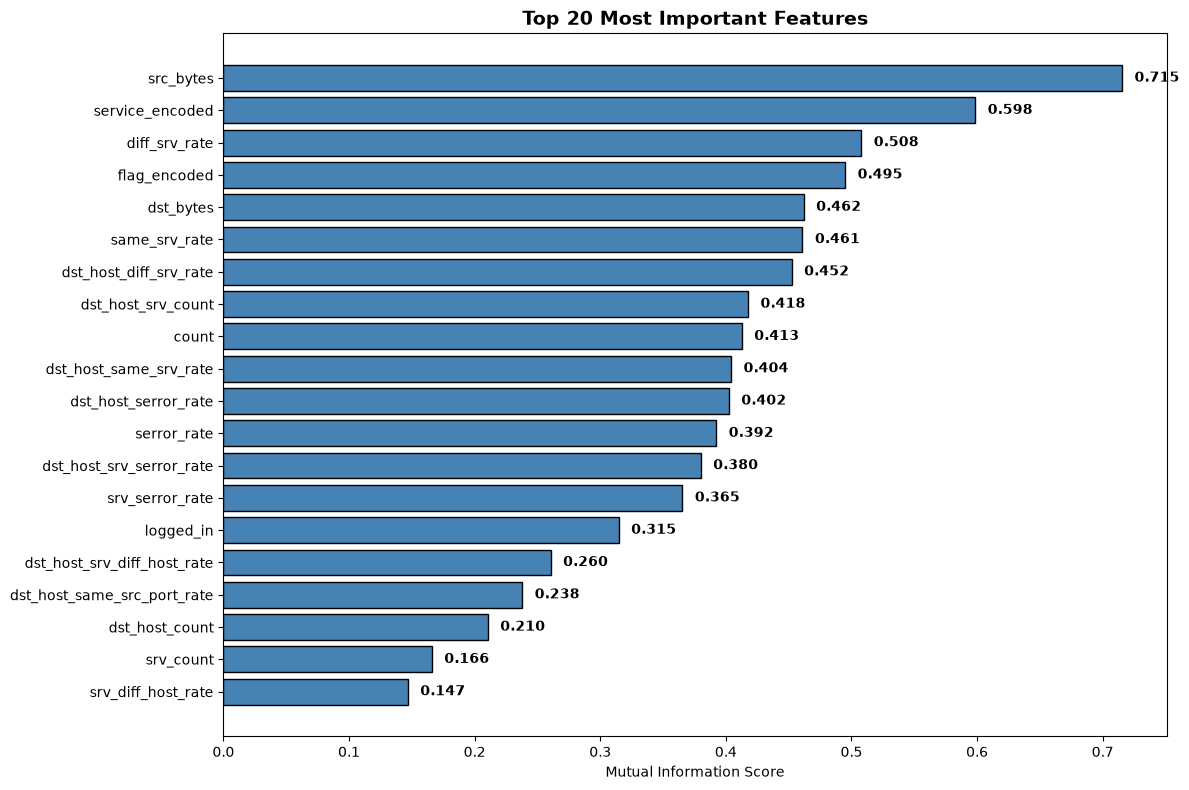


=== All Features Ranked ===
⭐ src_bytes                           0.7153
⭐ service_encoded                     0.5985
⭐ diff_srv_rate                       0.5078
⭐ flag_encoded                        0.4949
⭐ dst_bytes                           0.4619
⭐ same_srv_rate                       0.4610
⭐ dst_host_diff_srv_rate              0.4524
⭐ dst_host_srv_count                  0.4176
⭐ count                               0.4126
⭐ dst_host_same_srv_rate              0.4041
⭐ dst_host_serror_rate                0.4023
⭐ serror_rate                         0.3923
⭐ dst_host_srv_serror_rate            0.3800
⭐ srv_serror_rate                     0.3653
⭐ logged_in                           0.3147
⭐ dst_host_srv_diff_host_rate         0.2605
⭐ dst_host_same_src_port_rate         0.2378
⭐ dst_host_count                      0.2104
⭐ srv_count                           0.1659
⭐ srv_diff_host_rate                  0.1467
⭐ dst_host_rerror_rate                0.1005
   dst_host_srv_rerror_rat

In [5]:
# Calculate mutual information (how much each feature tells us about the target)
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': X_train.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(12, 8))
top20 = mi_df.head(20)
bars = ax.barh(range(len(top20)), top20['MI_Score'], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['Feature'])
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add score labels
for i, (score, name) in enumerate(zip(top20['MI_Score'], top20['Feature'])):
    ax.text(score + 0.01, i, f'{score:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== All Features Ranked ===')
for i, row in mi_df.iterrows():
    marker = '⭐' if row['MI_Score'] > 0.1 else '  '
    print(f"{marker} {row['Feature']:35s} {row['MI_Score']:.4f}")

In [6]:
# Select features with MI score > 0.05 (you can adjust this threshold)
selected_features = mi_df[mi_df['MI_Score'] > 0.05]['Feature'].tolist()
print(f'Selected {len(selected_features)} out of {len(mi_df)} features:\n')
for f in selected_features:
    print(f'  ✅ {f}')

# Create final datasets
X_train_final = X_train_scaled[selected_features]
X_test_final = X_test_scaled[selected_features]

# Save everything for the modeling notebook
X_train_final.to_csv('../data/X_train.csv', index=False)
X_test_final.to_csv('../data/X_test.csv', index=False)
pd.DataFrame({'y_train': y_train, 'y_train_binary': y_train_binary}).to_csv('../data/y_train.csv', index=False)
pd.DataFrame({'y_test': y_test, 'y_test_binary': y_test_binary}).to_csv('../data/y_test.csv', index=False)

print(f'\n📊 Final training set: {X_train_final.shape}')
print(f'📊 Final test set: {X_test_final.shape}')
print('\n✅ Data saved! Ready for ML modeling!')
print('🎉 Feature Engineering Complete! Next: Notebook 03 - ML Models')

Selected 26 out of 41 features:

  ✅ src_bytes
  ✅ service_encoded
  ✅ diff_srv_rate
  ✅ flag_encoded
  ✅ dst_bytes
  ✅ same_srv_rate
  ✅ dst_host_diff_srv_rate
  ✅ dst_host_srv_count
  ✅ count
  ✅ dst_host_same_srv_rate
  ✅ dst_host_serror_rate
  ✅ serror_rate
  ✅ dst_host_srv_serror_rate
  ✅ srv_serror_rate
  ✅ logged_in
  ✅ dst_host_srv_diff_host_rate
  ✅ dst_host_same_src_port_rate
  ✅ dst_host_count
  ✅ srv_count
  ✅ srv_diff_host_rate
  ✅ dst_host_rerror_rate
  ✅ dst_host_srv_rerror_rate
  ✅ protocol_type_encoded
  ✅ rerror_rate
  ✅ srv_rerror_rate
  ✅ duration

📊 Final training set: (125973, 26)
📊 Final test set: (22544, 26)

✅ Data saved! Ready for ML modeling!
🎉 Feature Engineering Complete! Next: Notebook 03 - ML Models
